# Brain Tumor Detection using Deep Learning

This notebook presents a deep learning-based approach for detecting and classifying brain tumors from MRI images. The model leverages *transfer learning* using a pre-trained **VGG16** architecture to achieve reliable performance on medical imaging data.

## Project Overview

The goal of this project is to build an automated system capable of identifying brain tumors from MRI scans. The model classifies images into four categories:

- **Glioma**
- **Meningioma**
- **Pituitary Tumor**
- **No Tumor**

The system is designed to assist in preliminary analysis by providing fast and consistent predictions.

## Problem Statement

Analyzing MRI scans manually requires expertise and can be time-intensive. This project aims to develop a deep learning model that can:

- Detect the presence of a tumor
- Classify the type of tumor when present
- Provide confidence-based predictions

The model is intended as a *support tool* and not a replacement for medical professionals.

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

## 2: Import Libraries

In [41]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from PIL import Image, ImageEnhance
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 3. Global Configuration

In [3]:
# ─── Paths ───────────────────────────────────────────────────────────────────
TRAIN_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
TEST_DIR  = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMAGE_SIZE  = 128      # Input size for VGG16 
BATCH_SIZE  = 32
EPOCHS_1    = 10       # Phase 1: train head only (base frozen)
EPOCHS_2    = 15       # Phase 2: fine-tune top VGG16 block

UNIQUE_LABELS = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES   = len(UNIQUE_LABELS)

print(f'Classes ({NUM_CLASSES}): {UNIQUE_LABELS}')
print(f'Label → Index mapping:')
for i, label in enumerate(UNIQUE_LABELS):
    print(f'  {i} → {label}')

Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']
Label → Index mapping:
  0 → glioma
  1 → meningioma
  2 → notumor
  3 → pituitary


## 4. Load Dataset Paths & Labels

## Dataset Description

The dataset consists of labeled MRI images categorized into four classes:

- *Glioma*
- *Meningioma*
- *Pituitary Tumor*
- *No Tumor*

The data is organized into separate directories for training and testing, ensuring proper evaluation without data leakage.

In [4]:
def load_paths_and_labels(directory):
    """Load all image paths and their string labels from a directory."""
    paths, labels = [], []
    for label in UNIQUE_LABELS:  # iterate in sorted order for consistency
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(class_dir, fname))
                labels.append(label)
    return paths, labels

train_paths, train_labels = load_paths_and_labels(TRAIN_DIR)
test_paths,  test_labels  = load_paths_and_labels(TEST_DIR)

# Shuffle training data
train_paths, train_labels = shuffle(train_paths, train_labels, random_state=SEED)
test_paths,  test_labels  = shuffle(test_paths,  test_labels,  random_state=SEED)

print(f'Training samples : {len(train_paths)}')
print(f'Testing  samples : {len(test_paths)}')
print()

# Class distribution
from collections import Counter
train_dist = Counter(train_labels)
test_dist  = Counter(test_labels)
print('Train distribution:', dict(sorted(train_dist.items())))
print('Test  distribution:', dict(sorted(test_dist.items())))

Training samples : 5600
Testing  samples : 1600

Train distribution: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Test  distribution: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


## 5. Data Visualization

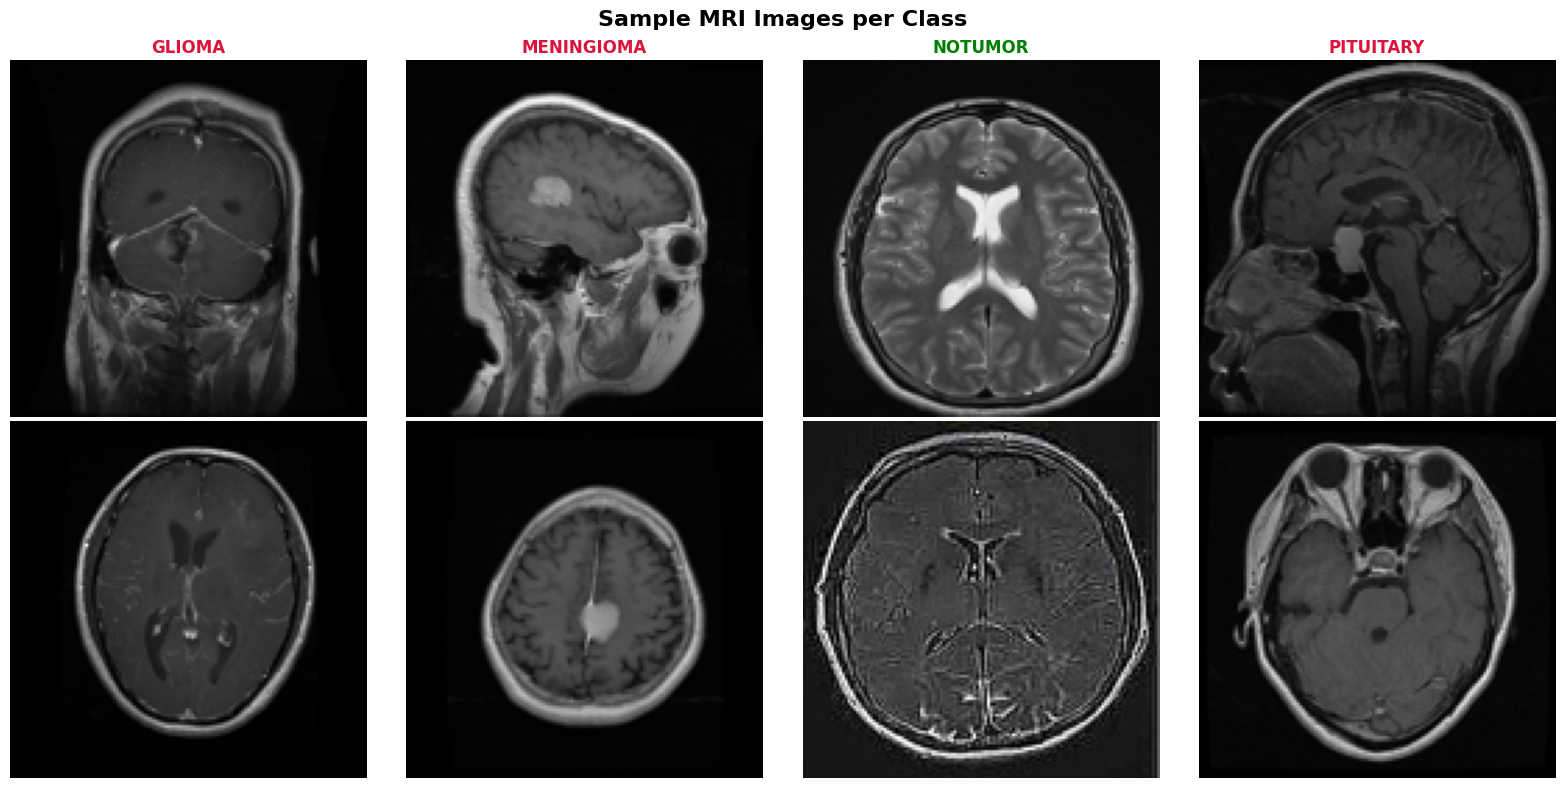

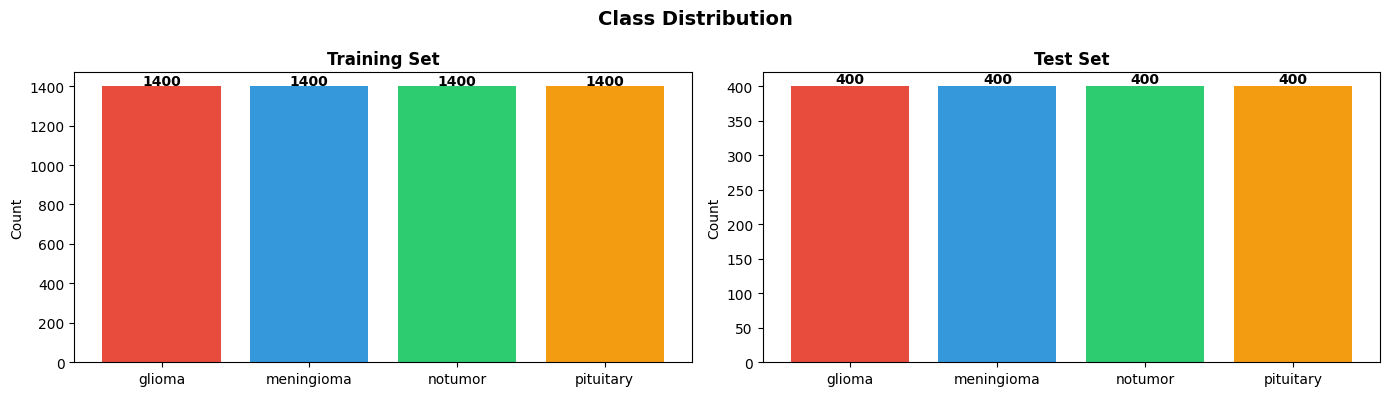

In [6]:
# Show sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample MRI Images per Class', fontsize=16, fontweight='bold')

for col, label in enumerate(UNIQUE_LABELS):
    # Pick 2 random images from each class
    class_paths = [p for p, l in zip(train_paths, train_labels) if l == label]
    samples = random.sample(class_paths, 2)
    for row, path in enumerate(samples):
        img = Image.open(path).resize((IMAGE_SIZE, IMAGE_SIZE))
        axes[row][col].imshow(img, cmap='gray' if img.mode == 'L' else None)
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(label.upper(), fontsize=12, fontweight='bold',
                                     color='crimson' if label != 'notumor' else 'green')

plt.tight_layout()
plt.show()

# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dist, title in zip(axes, [train_dist, test_dist], ['Training Set', 'Test Set']):
    bars = ax.bar(sorted(dist.keys()), [dist[k] for k in sorted(dist.keys())],
                  color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, [dist[k] for k in sorted(dist.keys())]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontweight='bold')
plt.suptitle('Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Preprocessing & Data Pipeline



## Data Preprocessing

To ensure consistency across all inputs, the following preprocessing steps are applied:

- Images are resized to **128 × 128 pixels**
- Pixel values are normalized to the range **[0, 1]**
- Labels are encoded into numerical format

During training, *data augmentation* is applied to improve generalization. This includes:

- Random horizontal flipping  
- Small rotations  
- Adjustments to brightness and contrast  

These transformations help the model learn more robust and invariant features.

In [7]:
def augment_image(image_array):
    """Apply random augmentations to a PIL-compatible image array."""
    image = Image.fromarray(np.uint8(image_array))
    # Random horizontal flip
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)
    # Random rotation (-20 to +20 degrees)
    angle = random.uniform(-20, 20)
    image = image.rotate(angle)
    # Random brightness
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    # Random contrast
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    return np.array(image)


def load_images(paths, augment=False):
    """
    Load images from disk, normalize to [0,1].
    augment=True  → apply random augmentation  (training only)
    augment=False → just normalize             (test / prediction)
    """
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img_array = img_to_array(img)          # shape: (H, W, 3), range 0–255
        if augment:
            img_array = augment_image(img_array)
        img_array = img_array / 255.0          # normalize to [0, 1]
        images.append(img_array)
    return np.array(images)


def encode_labels(labels):
    """
    FIX #1: Use the globally defined UNIQUE_LABELS (sorted) so
    the label→index mapping is ALWAYS the same across train / test / predict.
    """
    return np.array([UNIQUE_LABELS.index(label) for label in labels])


def data_generator(paths, labels, batch_size=BATCH_SIZE, augment=False):
    """Yields (images, encoded_labels) batches indefinitely."""
    n = len(paths)
    while True:
        # Shuffle at the start of each epoch
        indices = np.random.permutation(n)
        paths_  = [paths[i]  for i in indices]
        labels_ = [labels[i] for i in indices]
        for start in range(0, n, batch_size):
            bp = paths_[start:start + batch_size]
            bl = labels_[start:start + batch_size]
            yield load_images(bp, augment=augment), encode_labels(bl)


print('Preprocessing helpers defined.')
print(f'Label encoding check: {list(zip(UNIQUE_LABELS, encode_labels(UNIQUE_LABELS)))}')

Preprocessing helpers defined.
Label encoding check: [('glioma', np.int64(0)), ('meningioma', np.int64(1)), ('notumor', np.int64(2)), ('pituitary', np.int64(3))]


## 7.Model Architecture

The model is built using *transfer learning* with a pre-trained **VGG16** network.

> ### Key Design Choices

   - The convolutional base of VGG16 is used as a **feature extractor**
   - Fully connected layers are added on top for classification
   - Dropout is used to reduce overfitting

> ### Architecture Summary

  - Input: **128 × 128 × 3**
  - Base Model: *VGG16 (without top layers)*
  - Classification Head:
  - Flatten layer  
  - Dense layers with ReLU activation  
  - Dropout layers  
  - Final Softmax layer for multi-class classification

In [8]:
def build_model(num_classes, image_size=IMAGE_SIZE):

    base = VGG16(
        input_shape=(image_size, image_size, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze base
    for layer in base.layers:
        layer.trainable = False

    inputs = Input(shape=(image_size, image_size, 3))
    x = base(inputs)              # ✅ FIX (important)
    x = Flatten()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model, base
        
model, base_model = build_model(NUM_CLASSES)
model.summary()

trainable = sum(np.prod(v.shape) for v in model.trainable_weights)
total     = sum(np.prod(v.shape) for v in model.weights)
print(f'\nTrainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

I0000 00:00:1786797984.897078      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786797984.900190      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,845,508 (64.26 MB)

 Trainable params: 2,130,820 (8.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Trainable params: 2,130,820 / 16,845,508 (12.6%)


## 8. Training Strategy

Training is performed in two phases to effectively utilize transfer learning.

>  ### Phase 1: Training the Classification Head

- The VGG16 base is frozen
- Only the top dense layers are trained
- This allows the model to adapt to the dataset without altering pre-trained features

> ### Phase 2: Fine-Tuning

- The final convolutional block of VGG16 is unfrozen
- A lower learning rate is used
- The model adjusts deeper features to better suit MRI images

This approach improves performance while maintaining training stability.

In [9]:
# Compile for Phase 1
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

# Split off 15% of training data for validation
val_split = int(0.15 * len(train_paths))
val_paths,   val_labels   = train_paths[:val_split],  train_labels[:val_split]
fit_paths,   fit_labels   = train_paths[val_split:],  train_labels[val_split:]

steps_per_epoch  = len(fit_paths)  // BATCH_SIZE
validation_steps = len(val_paths)  // BATCH_SIZE

print(f'Train: {len(fit_paths)} | Val: {len(val_paths)} | Steps/epoch: {steps_per_epoch}')

callbacks_phase1 = [
    EarlyStopping(monitor='val_sparse_categorical_accuracy',
                  patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_phase1.keras', monitor='val_sparse_categorical_accuracy',
                    save_best_only=True, verbose=1)
]

print('\n=== PHASE 1: Training head (base frozen) ===')
history1 = model.fit(
    data_generator(fit_paths, fit_labels, augment=True),
    epochs=EPOCHS_1,
    steps_per_epoch=steps_per_epoch,
    validation_data=data_generator(val_paths, val_labels, augment=False),
    validation_steps=validation_steps,
    callbacks=callbacks_phase1
)

Train: 4760 | Val: 840 | Steps/epoch: 148

=== PHASE 1: Training head (base frozen) ===
Epoch 1/10
  2/148 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - loss: 1.9052 - sparse_categorical_accuracy: 0.3438 

I0000 00:00:1786798007.583957     140 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - loss: 1.0638 - sparse_categorical_accuracy: 0.5729
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.81130, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 55s 305ms/step - loss: 0.7903 - sparse_categorical_accuracy: 0.6786 - val_loss: 0.4825 - val_sparse_categorical_accuracy: 0.8113 - learning_rate: 0.0010
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.5382 - sparse_categorical_accuracy: 0.7852
Epoch 2: val_sparse_categorical_accuracy improved from 0.81130 to 0.87260, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - loss: 0.5231 - sparse_categorical_accuracy: 0.7951 - val_loss: 0.3488 - val_sparse_categorical_accuracy: 0.8726 - learning_rate: 0.0010
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.4491 - sparse_categorical_accuracy: 0.8201
Epoch 3

In [10]:
# Unfreeze the last conv block of VGG16 (block5: 4 layers)
for layer in base_model.layers:
    layer.trainable = 'block5' in layer.name

trainable_now = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f'Trainable params now: {trainable_now:,}')
print('Unfrozen layers:', [l.name for l in base_model.layers if l.trainable])

# Recompile with a much lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_sparse_categorical_accuracy',
                  patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_sparse_categorical_accuracy',
                    save_best_only=True, verbose=1)
]

print('\n=== PHASE 2: Fine-tuning top VGG16 block ===')
history2 = model.fit(
    data_generator(fit_paths, fit_labels, augment=True),
    epochs=EPOCHS_2,
    steps_per_epoch=steps_per_epoch,
    validation_data=data_generator(val_paths, val_labels, augment=False),
    validation_steps=validation_steps,
    callbacks=callbacks_phase2
)

Trainable params now: 9,210,244
Unfrozen layers: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']

=== PHASE 2: Fine-tuning top VGG16 block ===
Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.3134 - sparse_categorical_accuracy: 0.8752
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.89784, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 119ms/step - loss: 0.3006 - sparse_categorical_accuracy: 0.8847 - val_loss: 0.2690 - val_sparse_categorical_accuracy: 0.8978 - learning_rate: 1.0000e-05
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.2708 - sparse_categorical_accuracy: 0.9018
Epoch 2: val_sparse_categorical_accuracy improved from 0.89784 to 0.90505, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - loss: 0.2695 - sparse_categorical_accuracy: 0.9010 - val_loss: 0.2211 - val_spar

## 10: Training History Plots

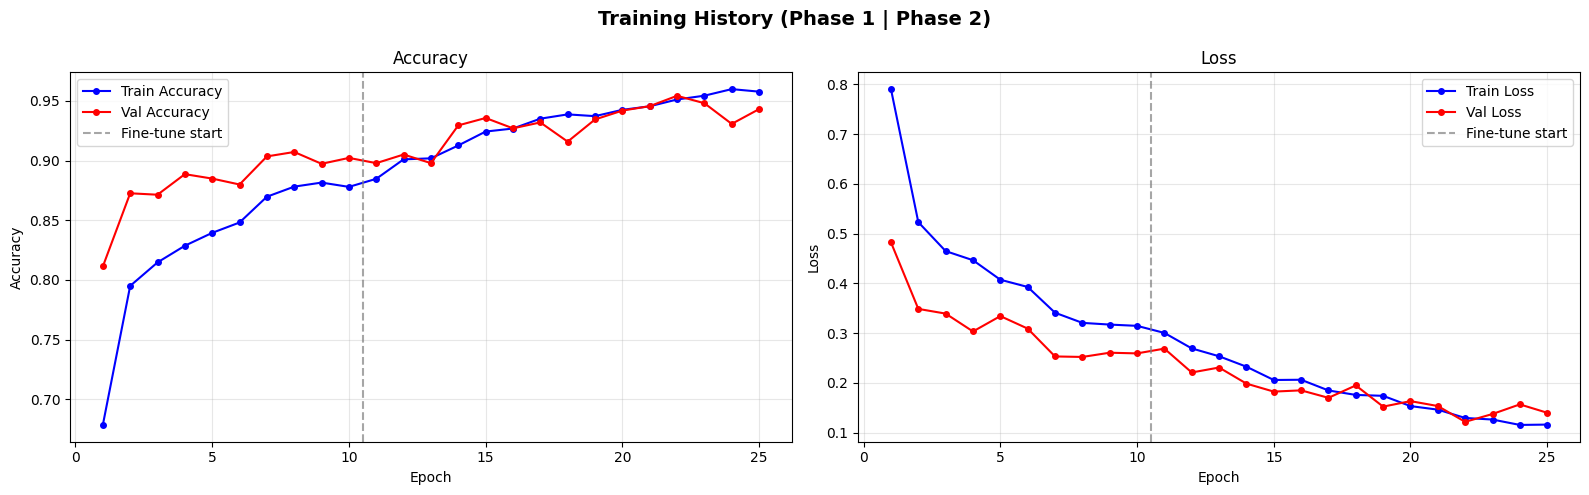

In [11]:
def merge_histories(h1, h2):
    """Concatenate Phase 1 and Phase 2 history dicts."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

history = merge_histories(history1, history2)
phase1_end = len(history1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training History (Phase 1 | Phase 2)', fontsize=14, fontweight='bold')

for ax, metric, label in zip(
    axes,
    ['sparse_categorical_accuracy', 'loss'],
    ['Accuracy', 'Loss']
):
    epochs_range = range(1, len(history[metric]) + 1)
    ax.plot(epochs_range, history[metric],        'b-o', markersize=4, label=f'Train {label}')
    ax.plot(epochs_range, history[f'val_{metric}'], 'r-o', markersize=4, label=f'Val {label}')
    ax.axvline(x=phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11: Full Evaluation on Test Set
   ### Model Evaluation

The model is evaluated using a separate test dataset.

The output is a probability distribution across all classes, allowing detailed interpretation of predictions.

Key metric used:

- **Accuracy** — measures overall prediction correctness

In [12]:
print('Loading test images (no augmentation)...')
# FIX #2: augment=False for test data — critical!
test_images  = load_images(test_paths, augment=False)
test_encoded = encode_labels(test_labels)

print(f'Test set shape: {test_images.shape}')
print('Running predictions...')
test_probs   = model.predict(test_images, batch_size=32, verbose=1)
test_preds   = np.argmax(test_probs, axis=1)

# Overall accuracy
accuracy = np.mean(test_preds == test_encoded)
print(f'\n✅ Test Accuracy: {accuracy*100:.2f}%')

# Classification Report
print('\n=== Classification Report ===')
print(classification_report(
    test_encoded, test_preds,
    target_names=UNIQUE_LABELS,
    digits=4
))

Loading test images (no augmentation)...
Test set shape: (1600, 128, 128, 3)
Running predictions...
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step

✅ Test Accuracy: 91.44%

=== Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9701    0.7300    0.8331       400
  meningioma     0.8297    0.9500    0.8858       400
     notumor     0.9172    0.9975    0.9557       400
   pituitary     0.9655    0.9800    0.9727       400

    accuracy                         0.9144      1600
   macro avg     0.9206    0.9144    0.9118      1600
weighted avg     0.9206    0.9144    0.9118      1600



## 12. Confusion Matrix

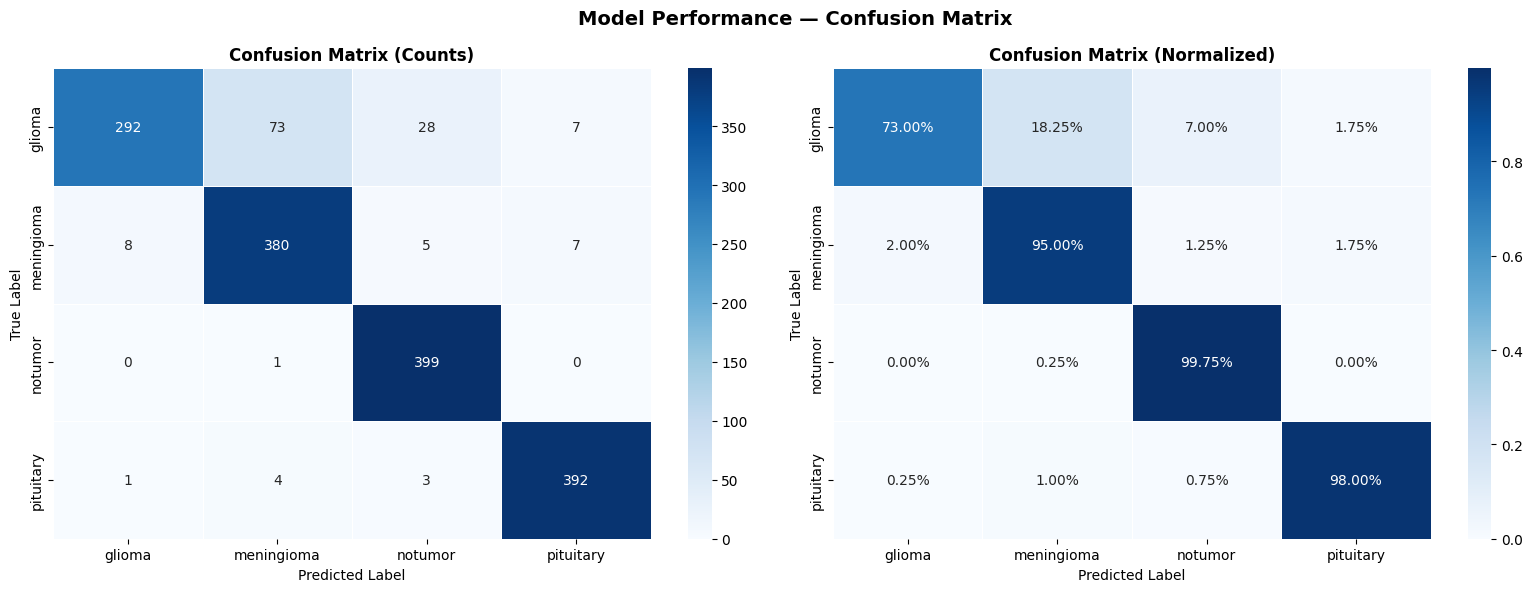

In [13]:
cm_matrix = confusion_matrix(test_encoded, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=UNIQUE_LABELS, yticklabels=UNIQUE_LABELS,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
cm_norm = cm_matrix.astype(float) / cm_matrix.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=UNIQUE_LABELS, yticklabels=UNIQUE_LABELS,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('Model Performance — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. ROC Curve & AUC per Class

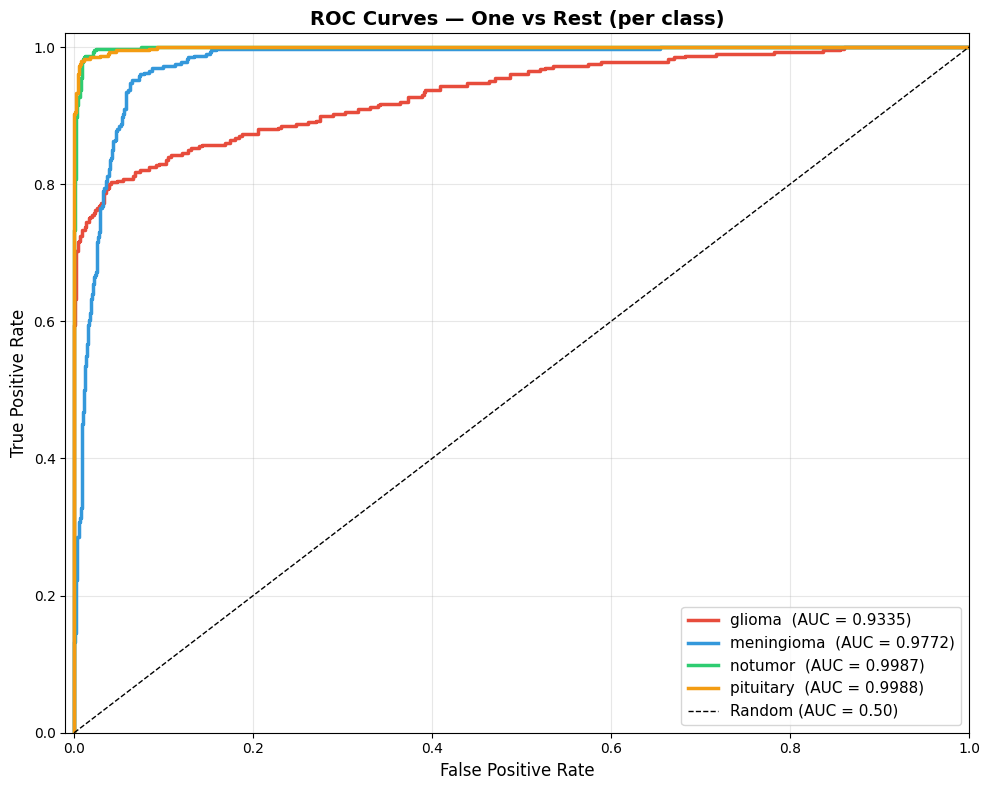

In [14]:
# Binarize for multi-class ROC
test_bin = label_binarize(test_encoded, classes=np.arange(NUM_CLASSES))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
plt.figure(figsize=(10, 8))

for i, (label, color) in enumerate(zip(UNIQUE_LABELS, colors)):
    fpr, tpr, _ = roc_curve(test_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{label}  (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — One vs Rest (per class)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14: Grad-CAM Visualization
See *exactly* which region of the MRI the model is looking at when making a prediction.

In [49]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='block4_conv3'):
    vgg = model.get_layer('vgg16')
    last_conv_layer = vgg.get_layer(last_conv_layer_name)

    # Stage 1: VGG's own input -> chosen conv layer's output
    last_conv_layer_model = tf.keras.models.Model(vgg.input, last_conv_layer.output)

    # Stage 2: replay everything AFTER this layer — now includes block5's
    # 3 conv layers + pool, not just pool like before — then your head.
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    vgg_layer_names = [l.name for l in vgg.layers]
    idx = vgg_layer_names.index(last_conv_layer_name)
    for layer in vgg.layers[idx + 1:]:
        x = layer(x)

    base_index = model.layers.index(vgg)
    for layer in model.layers[base_index + 1:]:
        x = layer(x)

    classifier_model = tf.keras.models.Model(classifier_input, x)

    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_layer_model(img_tensor)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index), float(tf.reduce_max(predictions))
         
def overlay_gradcam(img_path, model, image_size=IMAGE_SIZE):
    """Load an image, run Grad-CAM, and display the overlay."""
    # Load raw image (for display) and preprocessed (for model)
    raw_img = np.array(Image.open(img_path).convert("RGB").resize((image_size, image_size)))
    img_array = raw_img.astype(np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap, pred_idx, confidence = make_gradcam_heatmap(img_array, model)

    # Resize heatmap to image size
    heatmap_resized = np.array(Image.fromarray(np.uint8(heatmap * 255)).resize(
        (image_size, image_size), Image.BILINEAR))

    # Colorize
    colormap = plt.get_cmap('jet')
    heatmap_colored = colormap(heatmap_resized / 255.0)[:, :, :3]  # drop alpha
    heatmap_colored = np.uint8(heatmap_colored * 255)

    # Overlay
    if raw_img.ndim == 2:
        raw_img = np.stack([raw_img]*3, axis=-1)
    overlay = np.uint8(0.6 * raw_img + 0.4 * heatmap_colored)

    pred_label = UNIQUE_LABELS[pred_idx]
    return raw_img, heatmap_resized, overlay, pred_label, confidence


print('Grad-CAM functions defined.')

Grad-CAM functions defined.


## 15. Save Model

In [43]:
# Save in native Keras format (recommended)
model.save('brain_tumor_model.keras')
print('Model saved as brain_tumor_model.keras')

# Also save label mapping so you always know which index = which class
import json
label_map = {i: label for i, label in enumerate(UNIQUE_LABELS)}
with open('label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print('Label map saved as label_map.json')
print('Label mapping:', label_map)

Model saved as brain_tumor_model.keras
Label map saved as label_map.json
Label mapping: {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}


In [44]:
print(UNIQUE_LABELS)
print(label_map)

['glioma', 'meningioma', 'notumor', 'pituitary']
{0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}


## 16. Load Model (for future use)

In [45]:
from tensorflow.keras.models import load_model
import json

# Load model
model = load_model('brain_tumor_model.keras')

# Load label mapping
with open('label_map.json') as f:
    label_map = json.load(f)

# FIX #4: Derive UNIQUE_LABELS from the saved label_map (not os.listdir!)
UNIQUE_LABELS = [label_map[str(i)] for i in range(len(label_map))]

print('Model loaded successfully.')
print('Classes:', UNIQUE_LABELS)

Model loaded successfully.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 17: MRI Tumor Detection System
Clean prediction function — no augmentation, proper label mapping, Grad-CAM included.

## Inference Pipeline

The prediction process follows a structured pipeline:

1. Load the MRI image  
2. Resize and normalize the image  
3. Pass the image through the trained model  
4. Obtain probability scores for each class  
5. Select the class with the highest probability  

The model also outputs a confidence score for each prediction.

In [50]:
def predict_mri(img_path, model, image_size=IMAGE_SIZE, show_gradcam=True):
    """
    Full MRI prediction pipeline.
    - Loads and preprocesses the image (NO augmentation)
    - Predicts tumor type
    - Displays result with optional Grad-CAM overlay
    """
    try:
        # ── Load & preprocess 
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        # ── Predict
        probs = model.predict(img_batch, verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        pred_label = UNIQUE_LABELS[pred_idx]
        confidence = float(probs[pred_idx])

        # ── Result text 
        if pred_label == 'notumor':
            result_text = '✅ No Tumor Detected'
            title_color = 'green'
        else:
            result_text = f'⚠️ Tumor Detected: {pred_label.upper()}'
            title_color = 'red'

        # ── Display 
        if show_gradcam:
            try:
                raw, heatmap, overlay, _, _ = overlay_gradcam(
                    img_path, model, image_size
                )

                fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                axes[0].imshow(raw)
                axes[0].set_title('Original MRI', fontsize=11)

                axes[1].imshow(heatmap, cmap='jet')
                axes[1].set_title('Grad-CAM Heatmap', fontsize=11)

                axes[2].imshow(overlay)
                axes[2].set_title('Overlay', fontsize=11)

                for ax in axes:
                    ax.axis('off')

                fig.suptitle(
                    f'{result_text}\nConfidence: {confidence*100:.2f}%',
                    fontsize=14,
                    fontweight='bold',
                    color=title_color
                )

                plt.tight_layout()
                plt.show()

            except Exception as e:
                print("Grad-CAM error:", e)

                plt.figure(figsize=(5, 5))
                plt.imshow(np.array(Image.open(img_path)))
                plt.axis('off')
                plt.title(
                    f'{result_text}\n{confidence*100:.2f}%',
                    fontsize=13,
                    fontweight='bold',
                    color=title_color
                )
                plt.tight_layout()
                plt.show()

        else:
            plt.figure(figsize=(5, 5))
            plt.imshow(np.array(Image.open(img_path)))
            plt.axis('off')
            plt.title(
                f'{result_text}\n{confidence*100:.2f}%',
                fontsize=13,
                fontweight='bold',
                color=title_color
            )
            plt.tight_layout()
            plt.show()

        # ── Probability breakdown 
        print(f'\n{result_text}')
        print(f'Confidence: {confidence*100:.2f}%')
        print('\nProbability breakdown:')

        for label, prob in sorted(
            zip(UNIQUE_LABELS, probs),
            key=lambda x: -x[1]
        ):
            bar = '█' * int(prob * 30)
            marker = ' ←' if label == pred_label else ''
            print(f'  {label:15s} {prob*100:6.2f}%  {bar}{marker}')

        return pred_label, confidence, probs

    except Exception as e:
        print(f'Error processing image: {e}')
        return None, None, None


print('predict_mri() is ready to use!')

predict_mri() is ready to use!


## 18. Run Predictions — One from Each Class

MRI TUMOR DETECTION SYSTEM — Test Predictions

────────────────────────────────────────────────────────────
Testing with a glioma image...
────────────────────────────────────────────────────────────


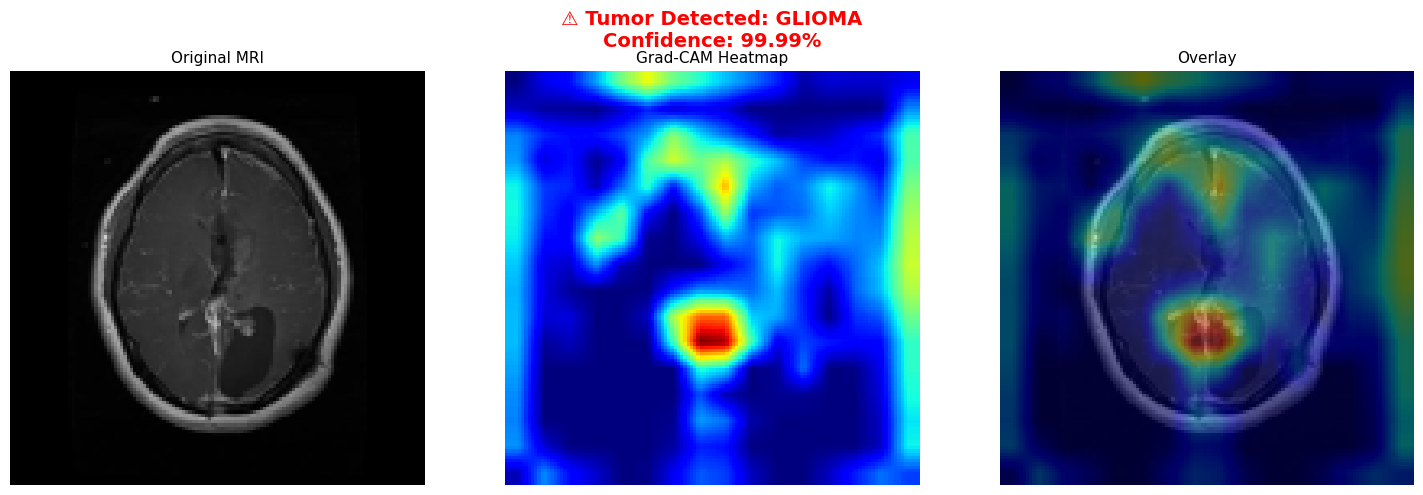


⚠️ Tumor Detected: GLIOMA
Confidence: 99.99%

Probability breakdown:
  glioma           99.99%  █████████████████████████████ ←
  meningioma        0.01%  
  notumor           0.00%  
  pituitary         0.00%  

────────────────────────────────────────────────────────────
Testing with a meningioma image...
────────────────────────────────────────────────────────────


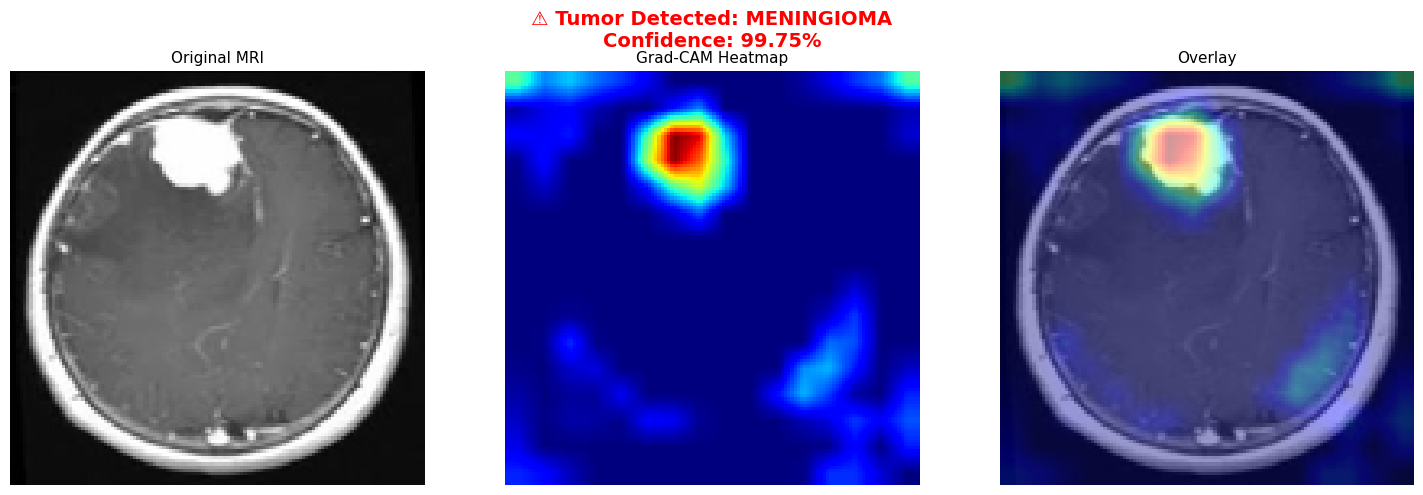


⚠️ Tumor Detected: MENINGIOMA
Confidence: 99.75%

Probability breakdown:
  meningioma       99.75%  █████████████████████████████ ←
  notumor           0.09%  
  pituitary         0.08%  
  glioma            0.08%  

────────────────────────────────────────────────────────────
Testing with a notumor image...
────────────────────────────────────────────────────────────


/tmp/ipykernel_58/534330160.py:56: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


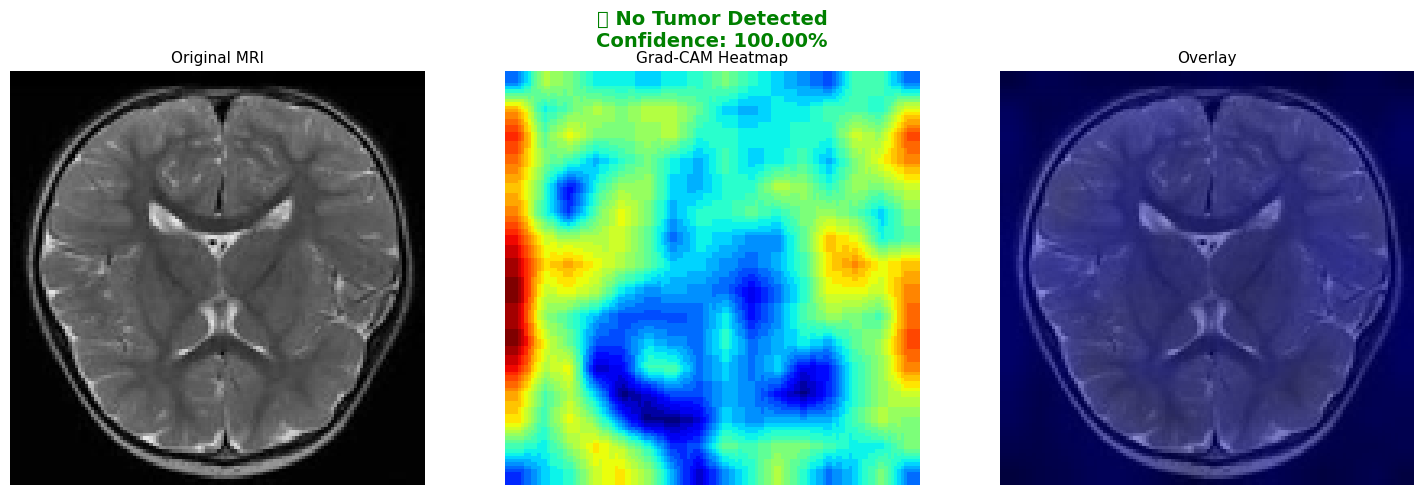


✅ No Tumor Detected
Confidence: 100.00%

Probability breakdown:
  notumor         100.00%  ██████████████████████████████ ←
  meningioma        0.00%  
  glioma            0.00%  
  pituitary         0.00%  

────────────────────────────────────────────────────────────
Testing with a pituitary image...
────────────────────────────────────────────────────────────


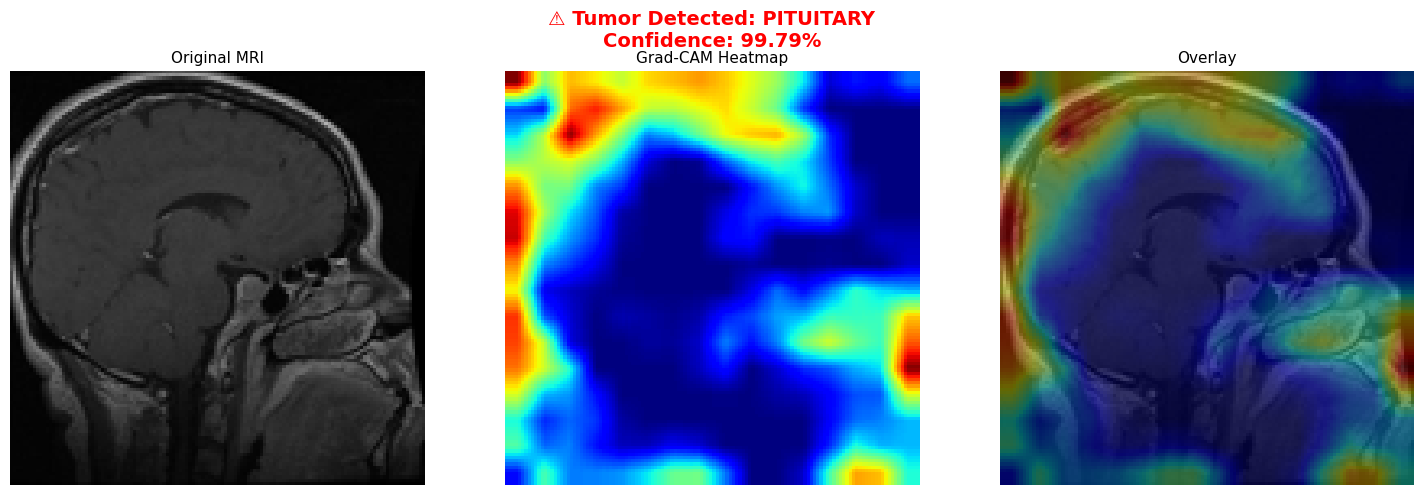


⚠️ Tumor Detected: PITUITARY
Confidence: 99.79%

Probability breakdown:
  pituitary        99.79%  █████████████████████████████ ←
  meningioma        0.19%  
  glioma            0.01%  
  notumor           0.01%  


In [56]:
print('=' * 60)
print('MRI TUMOR DETECTION SYSTEM — Test Predictions')
print('=' * 60)

for label in UNIQUE_LABELS:
    print(f'\n{"─"*60}')
    print(f'Testing with a {label} image...')
    print(f'{"─"*60}')

    class_paths = [p for p, l in zip(test_paths, test_labels) if l == label]

    if len(class_paths) == 0:
        print(f'⚠️ No images found for class: {label}')
        continue

    img_path = random.choice(class_paths)

    predict_mri(img_path, model, show_gradcam=True)

## 19. Predict Your Own Image
Upload any MRI image and get an instant prediction.

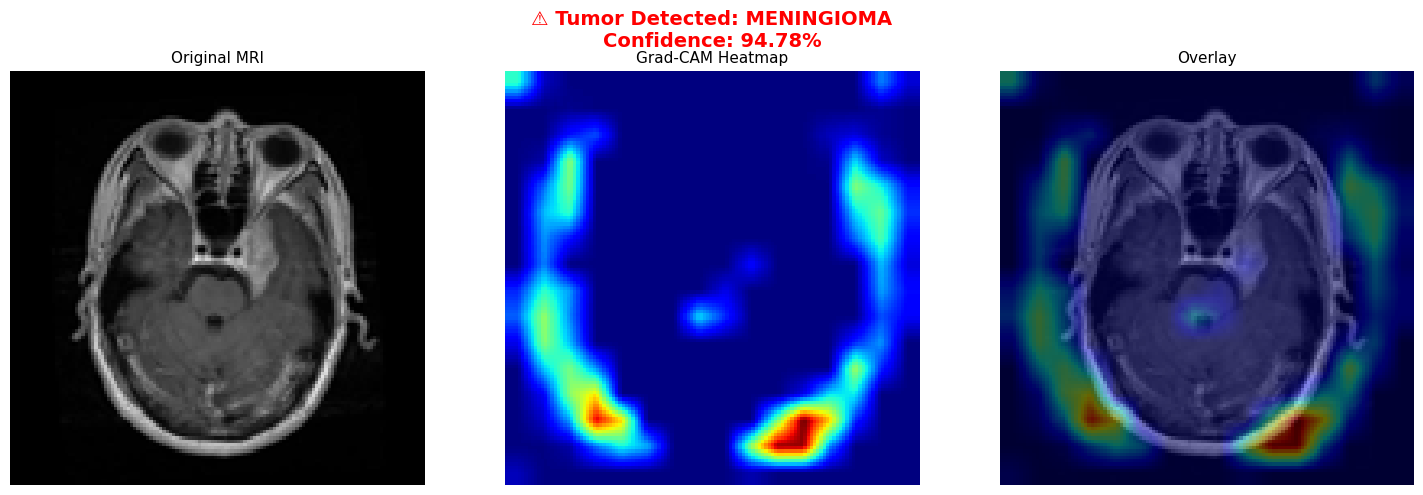


⚠️ Tumor Detected: MENINGIOMA
Confidence: 94.78%

Probability breakdown:
  meningioma       94.78%  ████████████████████████████ ←
  pituitary         4.12%  █
  glioma            1.07%  
  notumor           0.03%  


('meningioma',
 0.9478150606155396,
 array([1.06808115e-02, 9.47815061e-01, 3.00223532e-04, 4.12039533e-02],
       dtype=float32))

In [60]:
# ── Option A: provide a path directly 
custom_image_path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/meningioma/Te-aug-me_29.jpg'
predict_mri(custom_image_path, model, show_gradcam=True)

## Results Interpretation

Each prediction includes:

- The predicted class label  
- A confidence score  
- A probability distribution across all classes  

A high confidence score indicates strong model certainty, while lower values may indicate ambiguity between classes.

## Limitations

Despite achieving strong overall performance, the model exhibits certain limitations:

- Performance is dependent on the quality and diversity of the dataset  
- The model may not generalize well to unseen or differently distributed MRI data  
- It does not replace clinical diagnosis and should be used only as a supporting tool  

- Despite hyperparameter tuning, the model shows relatively lower *recall for glioma cases*.  
  This indicates that in some instances, glioma images are misclassified as *no tumor*,  
  leading to potential false negatives. This limitation is particularly important in a  
  medical context where missing a tumor can have serious implications.

## Conclusion

This project demonstrates the effectiveness of *transfer learning* in medical image classification. By leveraging a pre-trained model and fine-tuning it for a specific task, a reliable tumor classification system has been developed.

The model achieves strong performance while remaining computationally efficient, making it suitable for real-time applications.

## Future Work

Possible improvements include:

- Expanding the dataset for better generalization  
- Exploring advanced architectures such as *EfficientNet*  
- Enhancing interpretability using visualization techniques  
- Deploying the system in a scalable production environment  

## Final Note

This project is intended for *educational and research purposes only*. It should not be used for medical decision-making without professional consultation.